# XAINPATING

Aquest *notebook* recorre, de principi a fi, el pipeline del TFG sobre un **únic
parell** d'exemple, perquè cada pas sigui inspeccionable. No reprodueix la
generació massiva del dataset (això ho fan els scripts de `src/`), sinó que
n'explica la lògica i, sobretot, **com es mesura la fidelitat de l'explicació**.

**Flux:**

1. Selecció d'imatges COCO (1 cotxe, mida controlada)
2. Màscara de l'objecte (anotació + dilatació)
3. *Inpainting* amb LaMa → imatge contrafactual
4. Mètriques de qualitat d'imatge (PCP, MAPD, SSIM)
5. Classificador ResNet-18 (cotxe / sense cotxe)
6. **Integrated Gradients + Focus** sobre la *regió de diferència contrafactual*
7. Lectura agregada: la dissociació qualitat ↔ utilitat

> **Nota metodològica clau.** El *Focus* es calcula sobre la regió que **realment
> distingeix el parell** (la diferència de píxels entre original i contrafactual),
> **no** sobre la màscara semàntica de COCO. La màscara és la regió *prevista*; la
> diferència de píxels és la regió *real*. Vegeu el pas 6.


## 0. Configuració i imports

In [10]:
from pathlib import Path
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

DEVICE      = "mps" if torch.backends.mps.is_available() else "cpu"
DATASET_DIR = Path("../data/iopaint_dataset")
MODEL_PATH  = Path("../data/finetune/resnet18_car_classifier.pth")
IG_TARGET   = 1        # classe "amb cotxe"
DIFF_TAU    = 0.05     # llindar de la regió de diferència (en [0,1])
print("Device:", DEVICE)

Device: mps


## 1. Selecció d'imatges COCO

El criteri busca **causa única i bon *inpainting***: exactament un cotxe per
imatge (cap ambigüitat sobre què explica el model) i una mida intermèdia (prou
gran per ser rellevant, prou petita perquè el fons es reconstrueixi bé).

```python
# Resum dels filtres (vegeu src/generation.py):
N_CARS       = 1            # un sol cotxe
MIN_CAR_AREA = 0.10         # ≥ 10 % de l'àrea
MAX_CAR_AREA = 0.30         # ≤ 30 % de l'àrea
```

Aquí carreguem un parell ja generat pel pipeline per inspeccionar la resta del
flux.

In [11]:
metadata = json.loads((DATASET_DIR / "dataset_metadata.json").read_text())
entry = metadata[383]                       # un parell d'exemple
print("Parell:", entry["file_name"], "· àrea cotxe:", entry.get("car_area_pct"), "%")
entry

Parell: 000000460702.jpg · àrea cotxe: 21.5 %


{'image_id': 460702,
 'file_name': '000000460702.jpg',
 'img_path': '/Users/helveticka/xai-dataset/data/iopaint_dataset/images_original/000000460702.jpg',
 'mask_path': '/Users/helveticka/xai-dataset/data/iopaint_dataset/masks/000000460702.jpg',
 'inpainted_path': '/Users/helveticka/xai-dataset/data/iopaint_dataset/images_inpainted/000000460702.png',
 'car_area_pct': 21.5}

## 2. Màscara de l'objecte

La màscara surt directament de l'**anotació de segmentació de COCO** (evitem els
errors d'una segmentació automàtica) i es **dilata** uns píxels per assegurar que
no queden vores residuals del cotxe després de reconstruir.

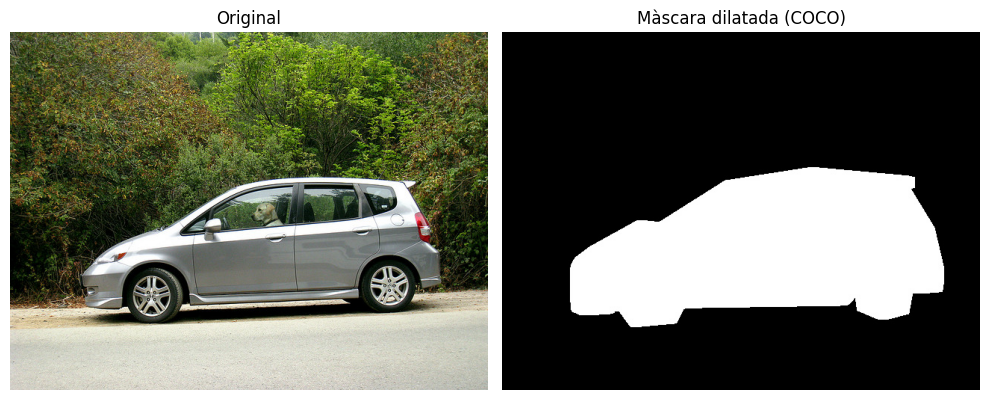

In [12]:
import cv2
orig = np.array(Image.open(entry["img_path"]).convert("RGB"))
mask = cv2.imread(entry["mask_path"], cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(orig); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Màscara dilatada (COCO)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 3. *Inpainting* amb LaMa → contrafactual

L'*inpainting* és una **tasca**, no una família de models: reconstruir una regió
absent condicionant-se al context. S'usa **LaMa** (local, via IOPaint) per una
propietat decisiva per a aquest treball: **només modifica la regió emmascarada** i
preserva la resta de la imatge intacta (PCP i MAPD exteriors ≈ 0). Així, el parell
difereix *únicament* en l'objecte, que és exactament el que exigeix un contrafactual
vàlid.

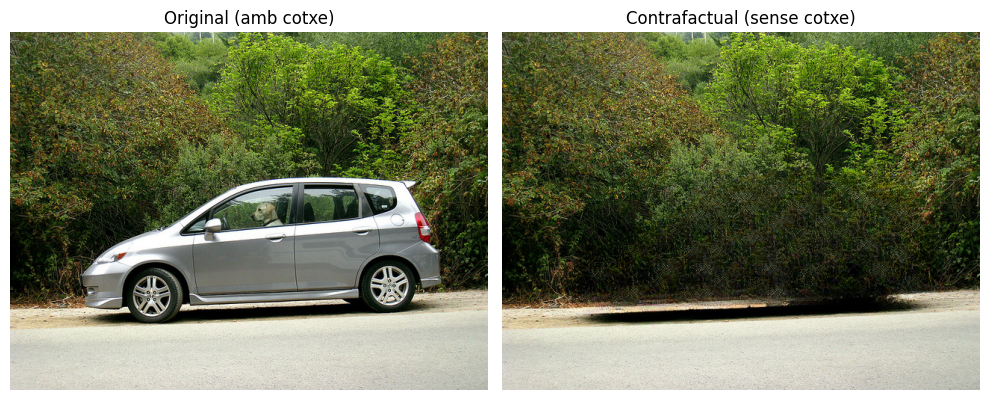

In [13]:
inp = np.array(Image.open(entry["inpainted_path"]).convert("RGB"))
if inp.shape != orig.shape:
    inp = np.array(Image.fromarray(inp).resize((orig.shape[1], orig.shape[0])))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(orig); ax[0].set_title("Original (amb cotxe)"); ax[0].axis("off")
ax[1].imshow(inp);  ax[1].set_title("Contrafactual (sense cotxe)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 4. Mètriques de qualitat d'imatge

Caracteritzen l'**empremta de la modificació** a tres nivells complementaris:

| Mètrica | Nivell | Què mesura |
|---|---|---|
| **PCP** | píxel (abast) | % de píxels alterats per sobre d'un llindar |
| **MAPD** | píxel (intensitat) | magnitud mitjana del canvi per píxel |
| **SSIM** | estructura | similitud en luminància, contrast i estructura |

Es calculen globalment i **a l'exterior de la màscara**: en un backend local com
LaMa, l'exterior hauria de ser ≈ 0. Aquestes mètriques descriuen *la imatge*; no
diuen res, per si soles, sobre la utilitat de l'explicació (pas 6).

In [14]:
from skimage.metrics import structural_similarity as ssim

diff = np.abs(orig.astype(float) - inp.astype(float)).mean(axis=2)
tau  = 5.0
pcp_g  = (diff > tau).mean() * 100
mapd_g = diff.mean()
ssim_g = ssim(orig, inp, channel_axis=2, data_range=255)

ext = (mask == 0)
pcp_ext  = (diff[ext] > tau).mean() * 100
mapd_ext = diff[ext].mean()

print(f"PCP global  : {pcp_g:6.2f} %   |  PCP exterior  : {pcp_ext:6.3f} %")
print(f"MAPD global : {mapd_g:6.3f}     |  MAPD exterior : {mapd_ext:6.3f}")
print(f"SSIM global : {ssim_g:6.4f}")

PCP global  :  24.13 %   |  PCP exterior  :  0.000 %
MAPD global : 22.702     |  MAPD exterior :  0.000
SSIM global : 0.7596


## 5. Classificador ResNet-18

ResNet-18 preentrenat a ImageNet, amb la capa final substituïda per una sortida
binària (cotxe / sense cotxe) i ajustada amb els propis parells contrafactuals.
El *fine-tuning* és imprescindible: un ResNet genèric amb prou feines reacciona a
la presència del cotxe; el model ajustat sí.

In [15]:
def carregar_model(path, device):
    m = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(512, 2)
    m.load_state_dict(torch.load(path, map_location=device))
    return m.eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
preprocess_vis = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor()])

def carregar(path):
    img = Image.open(path).convert("RGB")
    return preprocess(img).unsqueeze(0), preprocess_vis(img)

model = carregar_model(MODEL_PATH, DEVICE)
t_orig, v_orig = carregar(entry["img_path"])
t_inp,  v_inp  = carregar(entry["inpainted_path"])

with torch.no_grad():
    p_orig = F.softmax(model(t_orig.to(DEVICE)), 1)[0][IG_TARGET].item()
    p_inp  = F.softmax(model(t_inp.to(DEVICE)),  1)[0][IG_TARGET].item()
print(f"P(cotxe)  original: {p_orig:.3f}   contrafactual: {p_inp:.3f}   "
      f"caiguda: {p_orig - p_inp:+.3f}")

P(cotxe)  original: 0.997   contrafactual: 0.128   caiguda: +0.869


## 6. Integrated Gradients + Focus — el nucli metodològic

### 6.1 Atribució

Integrated Gradients assigna a cada píxel una **rellevància** respecte a la classe
"cotxe". Seguint la definició de *Focus* (Arias-Duart et al., 2022), n'agafem
**només la part positiva** i l'agreguem sobre els canals. **No** la normalitzem
min–max: el Focus és una *fracció* de la rellevància total i restar el mínim global
introduiria un biaix.

In [16]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(model)

def rellevancia_positiva(attr):
    a = attr.squeeze(0).detach().cpu().numpy()   # (3,224,224)
    return np.clip(a, 0, None).sum(axis=0)        # (224,224), només positiva

rel_orig = rellevancia_positiva(ig.attribute(t_orig.to(DEVICE), target=IG_TARGET, n_steps=50))
rel_inp  = rellevancia_positiva(ig.attribute(t_inp.to(DEVICE),  target=IG_TARGET, n_steps=50))

### 6.2 La regió de referència correcta

Aquí hi havia l'error que calia corregir. El *Focus* mesura **quina fracció de la
rellevància cau sobre la regió rellevant**. La pregunta és: *quina* regió?

- **La màscara de COCO** (la versió anterior): és la regió que *volíem* modificar.
- **La diferència de píxels entre el parell**: és la regió que *realment* ha
  canviat en eliminar l'objecte — la *regió que distingeix el parell*.

El paradigma contrafactual dóna la veritat de referència per construcció: l'única
cosa que separa les dues imatges és l'objecte, de manera que el que ha canviat
*és* l'evidència. Usar la diferència empírica, i no l'anotació, fa que:

- s'**exclogui** la part de la màscara que LaMa va deixar pràcticament intacta, i
- la mesura **no depengui** de cap etiqueta externa al parell.

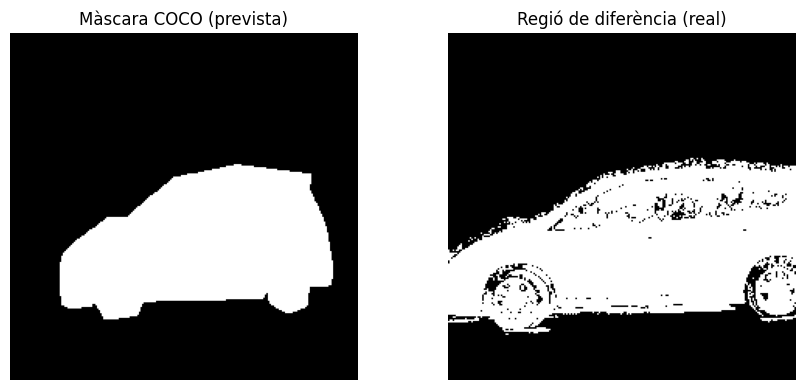

Àrea màscara COCO : 24.99 %
Àrea diferència   : 34.31 %  (= baseline aleatori del Focus)


In [17]:
def regio_diferencia(vis_orig, vis_inp, tau=DIFF_TAU):
    d = (vis_orig - vis_inp).abs().mean(0).numpy()   # diferència en [0,1]
    return d > tau

regio = regio_diferencia(v_orig, v_inp)
mask_224 = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST) > 127

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(mask_224, cmap="gray"); ax[0].set_title("Màscara COCO (prevista)"); ax[0].axis("off")
ax[1].imshow(regio,    cmap="gray"); ax[1].set_title("Regió de diferència (real)"); ax[1].axis("off")
plt.tight_layout(); plt.show()
print(f"Àrea màscara COCO : {mask_224.mean()*100:5.2f} %")
print(f"Àrea diferència   : {regio.mean()*100:5.2f} %  (= baseline aleatori del Focus)")

### 6.3 Focus i la seva lectura

El **Focus** és la fracció de rellevància dins la regió. El **baseline aleatori**
és l'àrea de la regió (la probabilitat que un píxel qualsevol hi caigui): un mètode
no millor que l'atzar tindria Focus ≈ baseline.

La **caiguda de Focus** (orig − contrafactual) és el senyal interessant: si el
model mirava l'objecte, en eliminar-lo la rellevància hauria de marxar d'aquella
regió i el Focus baixar.

In [18]:
def focus_score(rel, regio):
    total = rel.sum()
    return float(rel[regio].sum() / total) if total > 1e-12 else 0.0

f_orig   = focus_score(rel_orig, regio)
f_inp    = focus_score(rel_inp,  regio)
baseline = regio.mean()

print(f"Focus original      : {f_orig:.3f}")
print(f"Focus contrafactual : {f_inp:.3f}")
print(f"Caiguda de Focus    : {f_orig - f_inp:+.3f}")
print(f"Baseline aleatori   : {baseline:.3f}  ({'per sobre' if f_orig > baseline else 'per sota'} del baseline)")

Focus original      : 0.371
Focus contrafactual : 0.481
Caiguda de Focus    : -0.111
Baseline aleatori   : 0.343  (per sobre del baseline)


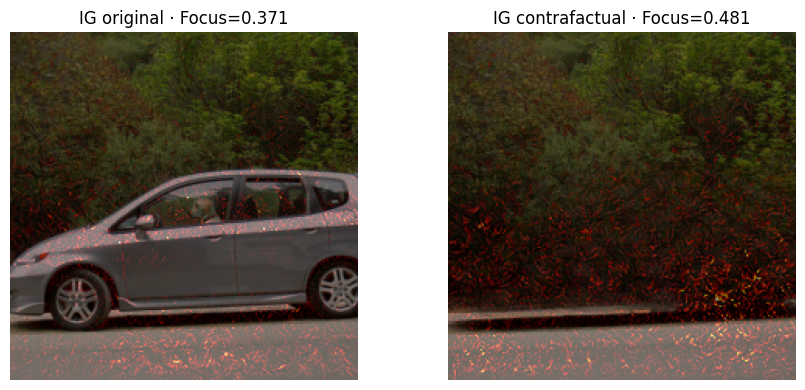

In [19]:
def heatmap(vis, rel, alpha=0.5):
    img = np.clip(vis.permute(1, 2, 0).numpy(), 0, 1)
    r = rel - rel.min(); r = r / r.max() if r.max() > 1e-12 else r
    return np.clip(img * (1 - alpha) + plt.cm.hot(r)[:, :, :3] * alpha, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(heatmap(v_orig, rel_orig)); ax[0].set_title(f"IG original · Focus={f_orig:.3f}"); ax[0].axis("off")
ax[1].imshow(heatmap(v_inp,  rel_inp));  ax[1].set_title(f"IG contrafactual · Focus={f_inp:.3f}"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 7. Lectura agregada: la dissociació

Sobre tot el dataset (vegeu `src/explanation.py`), es creuen dues famílies de
senyals que provenen de mons diferents:

- **Qualitat d'imatge** (PCP, MAPD, SSIM): com de bo és el contrafactual *com a
  imatge*.
- **Utilitat de l'explicació** (Focus, caiguda de probabilitat): què revela
  l'explicació *del model*.

L'argument central del treball és que **aquestes dues coses no es prediuen l'una a
l'altra**: un contrafactual de gran fidelitat visual no garanteix una explicació
més fidel, ni a la inversa. A més, cal recordar la tensió documentada al Marc
Teòric: segons el *Focus*, **Integrated Gradients tendeix a explicacions
quasi-aleatòries** respecte al model, tot i la seva solidesa axiomàtica — un punt
que s'ha de discutir en interpretar aquests resultats.

> Per a les estadístiques completes, executeu:
> ```bash
> python src/03_xai_analysis.py --dataset-dir data/iopaint_dataset --device mps
> ```
